In [40]:
import pandas as pd
df = pd.read_csv("wdbc.csv", sep="\t")
df.head()
df.shape


(569, 32)

In [41]:
df.columns = df.columns.str.strip()
df = df.drop(columns=["ID"], errors='ignore')
df["Diagnosis"] = df["Diagnosis"].map({"M":1, "B":0})

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

print("Missing values:", X.isnull().sum().sum())
print("\nClass distribution:\n", y.value_counts())

Missing values: 0

Class distribution:
 Diagnosis
0    357
1    212
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#scaling is importantfor knn beacause it uses distance 

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values = [1,3,5,7,9,11,15,21]
acc_list = []
f1_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    acc_list.append(acc)
    f1_list.append(f1)

    print("K:", k, "Accuracy:", acc, "F1:", f1)

K: 1 Accuracy: 0.9298245614035088 F1: 0.9024390243902439
K: 3 Accuracy: 0.9385964912280702 F1: 0.9113924050632911
K: 5 Accuracy: 0.956140350877193 F1: 0.9382716049382716
K: 7 Accuracy: 0.956140350877193 F1: 0.9382716049382716
K: 9 Accuracy: 0.9473684210526315 F1: 0.925
K: 11 Accuracy: 0.9473684210526315 F1: 0.925
K: 15 Accuracy: 0.9473684210526315 F1: 0.925
K: 21 Accuracy: 0.9385964912280702 F1: 0.9113924050632911


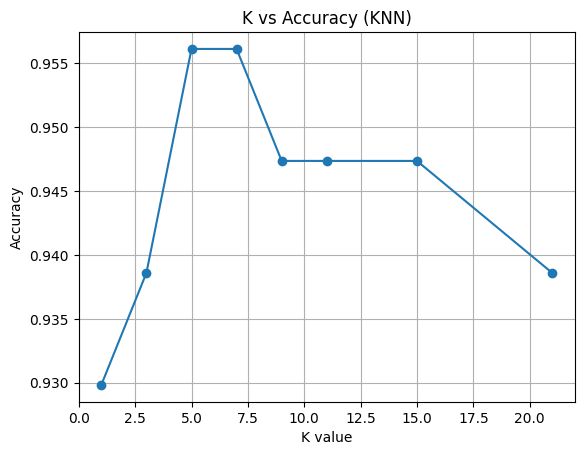

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, acc_list, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (KNN)")
plt.grid()
plt.show()

#The optimal K is the value where test accuracy is highest.
#It balances overfitting (low K) and underfitting (high K).

In [33]:
import numpy as np

best_k = k_values[np.argmax(acc_list)]
print("Best K:", best_k)
# When K is small, the model overfits and accuracy may be high but unstable.
#As K increases, accuracy improves and becomes stable.
#For very large K, accuracy may decrease due to underfitting.




Best K: 5


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, matthews_corrcoef
import pandas as pd


knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_mcc = matthews_corrcoef(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)
print("KNN F1:", knn_f1)
print("KNN Recall:", knn_recall)
print("KNN MCC:", knn_mcc)

print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))


lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_mcc = matthews_corrcoef(y_test, y_pred_lr)

print("\nLogistic Regression Accuracy:", lr_acc)
print("Logistic Regression F1:", lr_f1)
print("Logistic Regression MCC:", lr_mcc)


comparison = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression"],
    "Accuracy": [knn_acc, lr_acc],
    "F1 Score": [knn_f1, lr_f1],
    "MCC": [knn_mcc, lr_mcc]
})

print("\nComparison Table:")
print(comparison)

KNN Accuracy: 0.956140350877193
KNN F1: 0.9382716049382716
KNN Recall: 0.9047619047619048
KNN MCC: 0.9058238738943076

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Logistic Regression Accuracy: 0.9649122807017544
Logistic Regression F1: 0.9512195121951219
Logistic Regression MCC: 0.9245181185940877

Comparison Table:
                 Model  Accuracy  F1 Score       MCC
0                  KNN  0.956140  0.938272  0.905824
1  Logistic Regression  0.964912  0.951220  0.924518


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("TPR:", TP/(TP+FN))
print("TNR:", TN/(TN+FP))
print("FPR:", FP/(FP+TN))
print("FNR:", FN/(FN+TP))
#The error with the higher rate (FPR or FNR) is more prevalent.

Confusion Matrix:
 [[71  1]
 [ 4 38]]
TPR: 0.9047619047619048
TNR: 0.9861111111111112
FPR: 0.013888888888888888
FNR: 0.09523809523809523


In [22]:
from sklearn.model_selection import LeaveOneOut

X_sub = X_train[:100]
y_sub = y_train.iloc[:100]

loo = LeaveOneOut()
scores = []

for train_idx, test_idx in loo.split(X_sub):
    X_train, X_test = X_sub[train_idx], X_sub[test_idx]
    y_train, y_test = y_sub.iloc[train_idx], y_sub.iloc[test_idx]

    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    scores.append(pred[0] == y_test.values[0])

print("LOO Accuracy:", sum(scores)/len(scores))

LOO Accuracy: 0.97


In [27]:
# For K=1 
#  model is overfitting
# Training accuracy ~100% but test accuracy is lower

In [28]:
#MCC is usually lower than F1
#F1 looks only at positive cases
#MCC considers all types of results
#So MCC gives a more complete picture
#MCC is better
#Because it considers both types of mistakes

In [32]:
#Cancer tissue is usually bigger and not regular in shape
#most case found correctly and some cases not found correctly
#So a few people may be wrongly flagged
#Overall, there is a clear difference but some overlap